In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
sns.set_theme(style='whitegrid')

DATA    = joblib.load("../../04_machine_learning/models/data_splits.pkl")
X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, FEATURES = DATA
results = joblib.load("../../04_machine_learning/models/all_results.pkl")
model   = joblib.load("../../04_machine_learning/models/model_final.pkl")

print("✅ Tout chargé")
print(f"   Modèle final : {type(model).__name__}")

✅ Tout chargé
   Modèle final : XGBClassifier


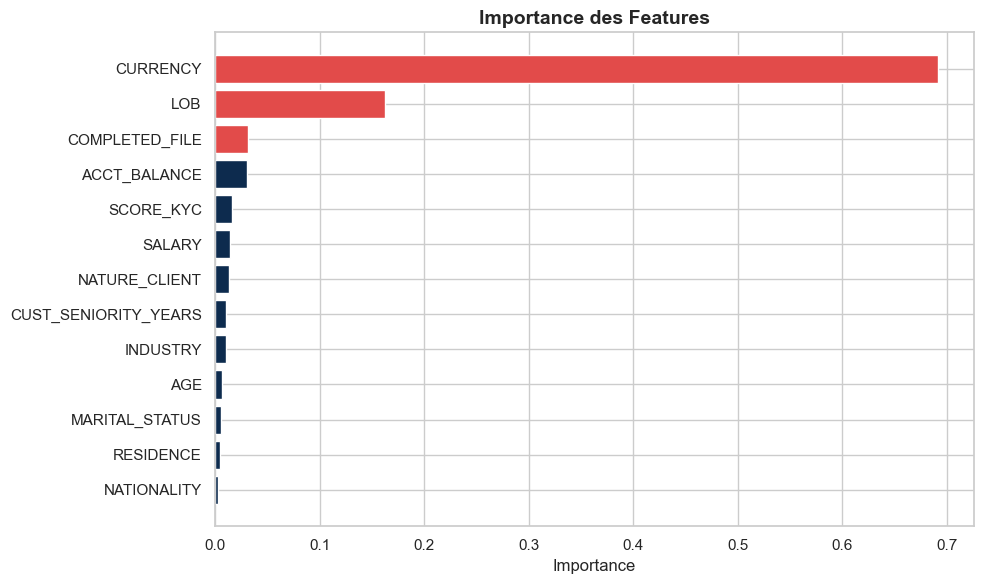

✅ Feature importance sauvegardée


In [9]:
if hasattr(model, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'Feature'   : FEATURES,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors_bars = ['#E24B4A' if i >= len(imp_df)-3 else '#0D2B4E'
                   for i in range(len(imp_df))]
    ax.barh(imp_df['Feature'], imp_df['Importance'],
            color=colors_bars, edgecolor='white')
    ax.set_title('Importance des Features', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')

    plt.tight_layout()
    plt.savefig("../../04_machine_learning/models/feature_importance.png", dpi=150)
    plt.show()
    print("✅ Feature importance sauvegardée")

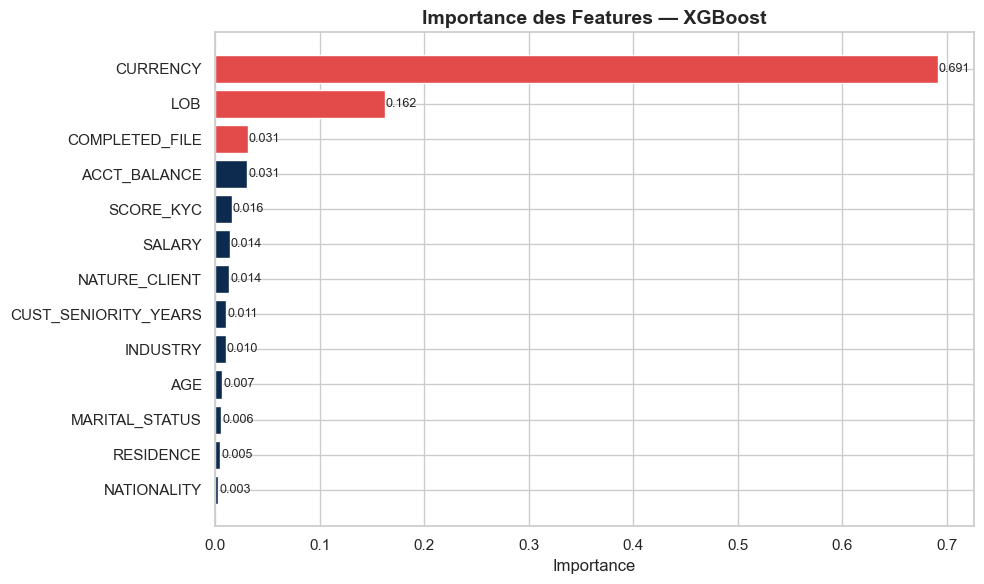

✅ Feature importance sauvegardée

Top 5 features :
       Feature  Importance
      CURRENCY    0.691201
           LOB    0.162256
COMPLETED_FILE    0.031158
  ACCT_BALANCE    0.030830
     SCORE_KYC    0.015991


In [8]:
# Feature importance native XGBoost (remplace SHAP)
import pandas as pd
import matplotlib.pyplot as plt

imp_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

# Bar plot horizontal
fig, ax = plt.subplots(figsize=(10, 6))
colors_bars = ['#E24B4A' if i >= len(imp_df)-3 else '#0D2B4E'
               for i in range(len(imp_df))]
ax.barh(imp_df['Feature'], imp_df['Importance'],
        color=colors_bars, edgecolor='white')
ax.set_title('Importance des Features — XGBoost', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
for i, (val, name) in enumerate(zip(imp_df['Importance'], imp_df['Feature'])):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("../../04_machine_learning/models/feature_importance.png", dpi=150)
plt.show()
print("✅ Feature importance sauvegardée")
print("\nTop 5 features :")
print(imp_df.tail(5)[['Feature','Importance']].iloc[::-1].to_string(index=False))

In [10]:
print("=" * 55)
print("     RÉSUMÉ FINAL — MACHINE LEARNING")
print("=" * 55)

best = max(results, key=lambda x: results[x]['ROC-AUC'])
for name, res in results.items():
    tag = "🏆" if name == best else "  "
    print(f"\n{tag} {name}")
    print(f"   ROC-AUC : {res['ROC-AUC']:.4f}")
    print(f"   PR-AUC  : {res['PR-AUC']:.4f}")
    print(f"   F1-Score: {res['F1']:.4f}")

print("\n" + "=" * 55)
print("✅ Évaluation terminée — Prêt pour Streamlit !")
print("=" * 55)

     RÉSUMÉ FINAL — MACHINE LEARNING

   Logistic Regression
   ROC-AUC : 0.6940
   PR-AUC  : 0.6385
   F1-Score: 0.5371

   Random Forest
   ROC-AUC : 0.9402
   PR-AUC  : 0.9479
   F1-Score: 0.8614

🏆 XGBoost
   ROC-AUC : 0.9496
   PR-AUC  : 0.9562
   F1-Score: 0.8805

✅ Évaluation terminée — Prêt pour Streamlit !
